In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import os
from datetime import datetime
import tensorflow as tf
from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers, callbacks
TENSORFLOW_AVAILABLE = True


all_data = pd.read_csv('breast-cancer.csv')
all_data = all_data.drop(columns=['id'])

Данные представляют собой статистику рака груди, собранную в университете Висконсина. Столбцов: 32, все данные числовые. Цель - предсказать состояние опухоли: M - злокачественная, B - доброкачественная. Ссылка: https://www.kaggle.com/datasets/imtkaggleteam/breast-cancer

In [ ]:
label_encoder = LabelEncoder()
all_data['diagnosis'] = label_encoder.fit_transform(all_data['diagnosis'])

X = all_data.drop(columns=['diagnosis'])
y = all_data['diagnosis']

print(f"Распределение классов:\n{y.value_counts()}")    

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Распределение классов:
diagnosis
0    357
1    212
Name: count, dtype: int64


Теперь M/B -> 0/1. Разделили данные: X - строки без таргетной переменной, y - столбец с диагнозами. Разделили данные 80 на 20. Злокачественных - 357, доброкачественных - 212.

In [ ]:
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_scaled_minmax = scaler_minmax.fit_transform(X_train)
X_test_scaled_minmax = scaler_minmax.transform(X_test)

X_train_binary = (X_train_scaled_minmax > 0.5).astype(int)
X_test_binary = (X_test_scaled_minmax > 0.5).astype(int)

Нормализируем обучающие и тренировочные данные через standartscaler для гауссовской наивной байесовской классификации.
Нормализуем обучающие и тренировочные данные через MinMaxScaler(для неотрицательных значений) для мультиномиального и комплементарного классификаторов.
Произведем бинаризацию для бернуллиевского классификатора. Если стандартизированная минимаксом запись > 0.5, то запись равняется 1 и наоборот.

In [ ]:
def calculate_metrics(y_true, y_pred, y_proba):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba)
    }
    return metrics


def plot_roc_curves(y_true, y_proba_dict, model_names):
    plt.figure(figsize=(10, 8))
    
    for name in model_names:
        if name in y_proba_dict:
            fpr, tpr, _ = roc_curve(y_true, y_proba_dict[name])
            auc = roc_auc_score(y_true, y_proba_dict[name])
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Доля ложноположительных результатов (False Positive Rate)', fontsize=12)
    plt.ylabel('Доля истинноположительных результатов (True Positive Rate)', fontsize=12)
    plt.title('ROC кривые классификаторов', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_metrics_bar_charts(metrics_dict, model_names):
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    _, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
    
    for idx, metric in enumerate(metric_names):
        ax = axes[idx]
        values = [metrics_dict[name][metric] for name in model_names if name in metrics_dict]
        names = [name for name in model_names if name in metrics_dict]
        
        bars = ax.bar(range(len(names)), values, color=colors[:len(names)], edgecolor='black', linewidth=1.2)
        ax.set_xlabel('Классификатор', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_title(f'{metric} для различных классификаторов', fontsize=12, fontweight='bold')
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_ylim([0, 1.1])
        ax.grid(True, alpha=0.3, axis='y')
        
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

Возвращаем словарь с метриками из функции calculate_metrics. Отображаем ROC кривые и считаем площадь под ними в plot_roc_curves. Рисуем столбчатые диаграммы для метрик(Accuracy, Precision, Recall, F1-Score).

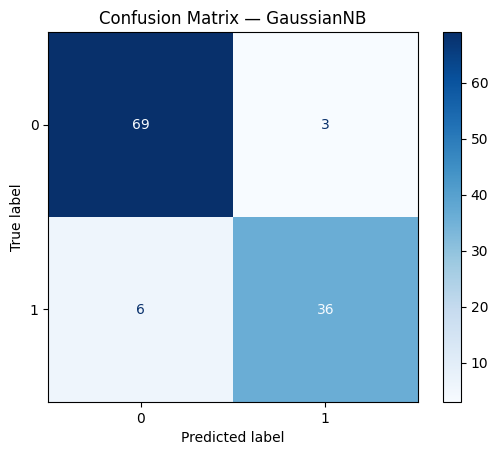

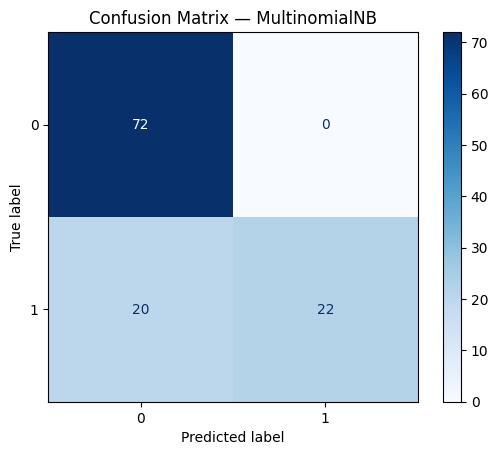

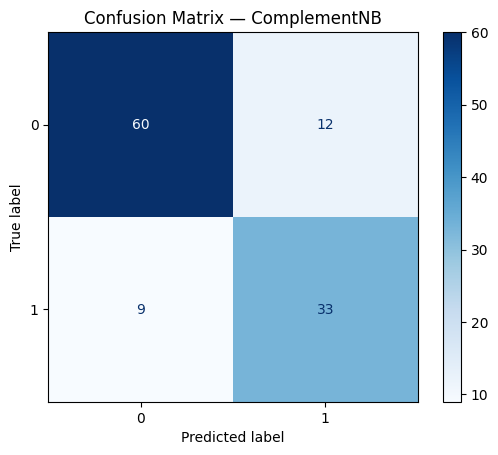

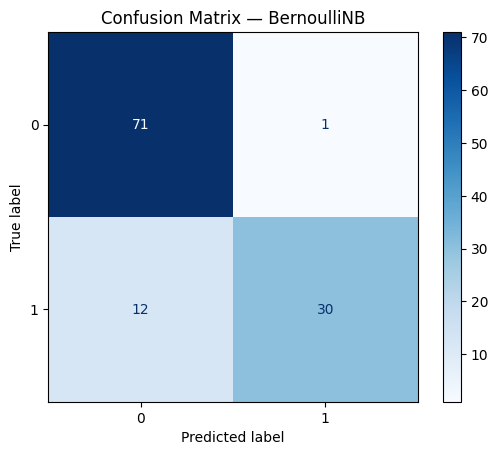

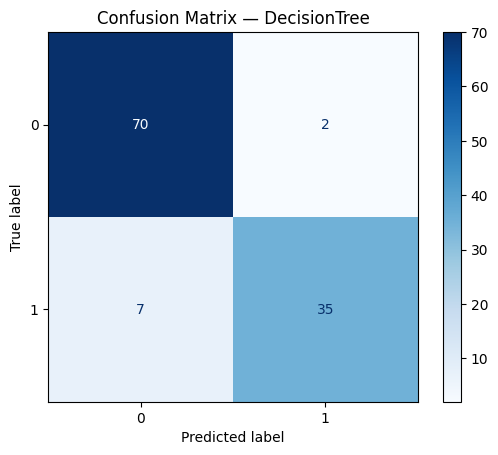

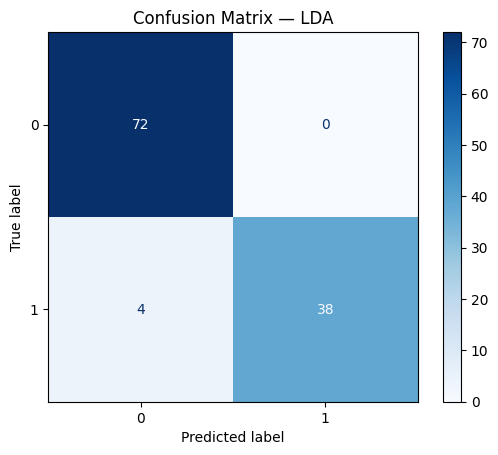

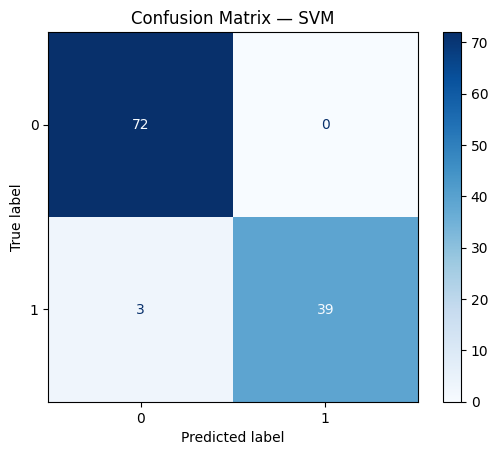

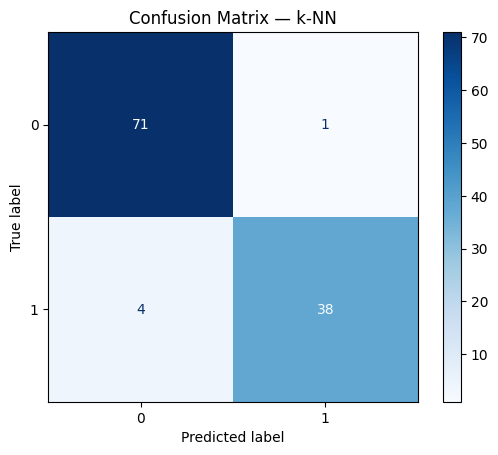


Построение ROC кривых...


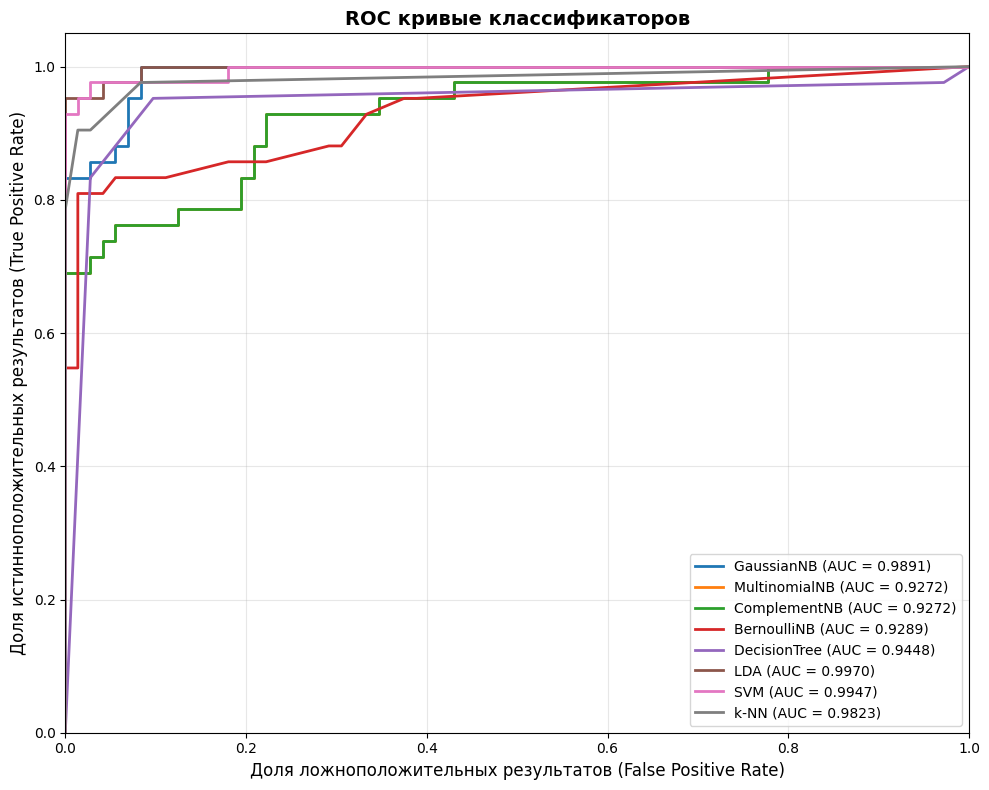


Построение столбчатых диаграмм метрик...


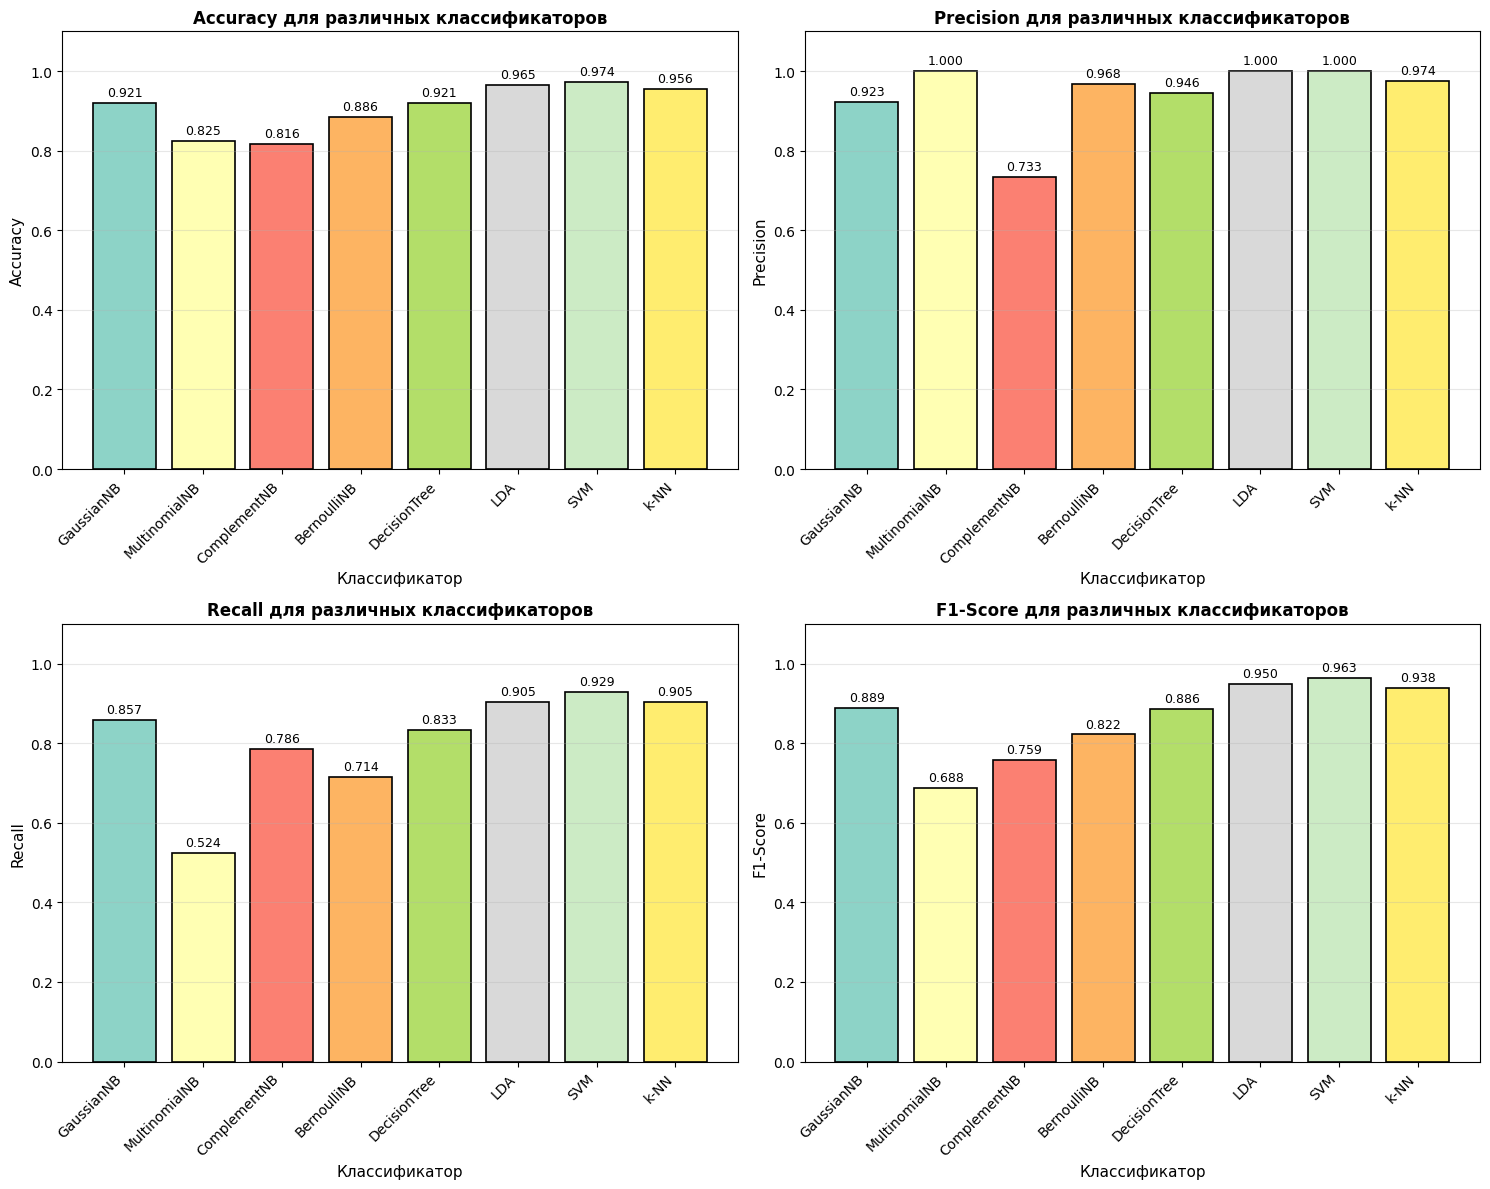

In [ ]:
classifiers = {}
results = {}
y_proba_dict = {}

gnb = GaussianNB()
gnb.fit(X_train_scaled_std, y_train)
y_pred_gnb = gnb.predict(X_test_scaled_std)
y_proba_gnb = gnb.predict_proba(X_test_scaled_std)[:, 1]
classifiers['GaussianNB'] = gnb
results['GaussianNB'] = {
    'predictions': y_pred_gnb
}
y_proba_dict['GaussianNB'] = y_proba_gnb

mnb = MultinomialNB()
mnb.fit(X_train_scaled_minmax, y_train)
y_pred_mnb = mnb.predict(X_test_scaled_minmax)
y_proba_mnb = mnb.predict_proba(X_test_scaled_minmax)[:, 1]
classifiers['MultinomialNB'] = mnb
results['MultinomialNB'] = {
    'predictions': y_pred_mnb
}
y_proba_dict['MultinomialNB'] = y_proba_mnb

cnb = ComplementNB()
cnb.fit(X_train_scaled_minmax, y_train)
y_pred_cnb = cnb.predict(X_test_scaled_minmax)
y_proba_cnb = cnb.predict_proba(X_test_scaled_minmax)[:, 1]
classifiers['ComplementNB'] = cnb
results['ComplementNB'] = {
    'predictions': y_pred_cnb
}
y_proba_dict['ComplementNB'] = y_proba_cnb

bnb = BernoulliNB()
bnb.fit(X_train_binary, y_train)
y_pred_bnb = bnb.predict(X_test_binary)
y_proba_bnb = bnb.predict_proba(X_test_binary)[:, 1]
classifiers['BernoulliNB'] = bnb
results['BernoulliNB'] = {
    'predictions': y_pred_bnb
}
y_proba_dict['BernoulliNB'] = y_proba_bnb

dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]
classifiers['DecisionTree'] = dt
results['DecisionTree'] = {
    'predictions': y_pred_dt
}
y_proba_dict['DecisionTree'] = y_proba_dt

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled_std, y_train)
y_pred_lda = lda.predict(X_test_scaled_std)
y_proba_lda = lda.predict_proba(X_test_scaled_std)[:, 1]
classifiers['LDA'] = lda
results['LDA'] = {
    'predictions': y_pred_lda
}
y_proba_dict['LDA'] = y_proba_lda

svm = SVC(random_state=42, probability=True)
svm.fit(X_train_scaled_std, y_train)
y_pred_svm = svm.predict(X_test_scaled_std)
y_proba_svm = svm.predict_proba(X_test_scaled_std)[:, 1]
classifiers['SVM'] = svm
results['SVM'] = {
    'predictions': y_pred_svm
}
y_proba_dict['SVM'] = y_proba_svm

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled_std, y_train)
y_pred_knn = knn.predict(X_test_scaled_std)
y_proba_knn = knn.predict_proba(X_test_scaled_std)[:, 1]
classifiers['k-NN'] = knn
results['k-NN'] = {
    'predictions': y_pred_knn
}
y_proba_dict['k-NN'] = y_proba_knn

for name, data in results.items():
    y_pred = data['predictions']
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

model_names = list(classifiers.keys())

comparison_metrics = {}
for name in model_names:
    y_pred = results[name]['predictions']
    y_proba = y_proba_dict[name]
    
    comparison_metrics[name] = calculate_metrics(y_test.values, y_pred, y_proba)

print("\nПостроение ROC кривых...")
plot_roc_curves(y_test.values, y_proba_dict, model_names)
print("\nПостроение столбчатых диаграмм метрик...")
plot_metrics_bar_charts(comparison_metrics, model_names)

Применим модели классификации и визуализируем результаты. Выведем confusion matrix для каждой модели, дерево решений, столбчатые диаграммы для метрик.
Сравним модели по метрикам.
Точность: Наиболее точными можно считать метод опорных векторов(0.974), линейный дискриминантый анализ(0.965) и метод ближайших соседей(0.956), наименее точными - комплементарный(0.816) и мультиномиальный(0.825) НБК.
Precision: Precision - доля правильно распознанных положительных ответов среди всех предположительно истинных ответов. Лучшие показатели здесь имеют LDA, SVM и мультиномиальный НБК(все 1), худший - комплементарный(0.733).
Recall: Recall отображает долю правильно распознанных положительных ответов относительно истинноположительных ответов. Тройка лидеров здесь та же, что и раньше, худший результат у мультиномиального НБК(0.524).
F1 score: мера f1 - метрика, показывающая баланс между Precision и Recall. Здесь ситауция схожа с предыдущими двумя метриками, за исключением мультиномиальной НКБ, т.к. Recall этой модели довольно низкий.
AUC-ROC: Кривая ROC - это график зависимости recall от FPR(доля ложноположительных среди всех отрицательных). Чтобы построить ROC, модель должна предсказывать вероятности отношения к классу. AUC-ROC - площадь под кривой(чем больше, тем лучше, макс. = 1). Лучше всего показали себя SVM, LDA, k-NN, гауссовский НБК. Худшие - комплементарный и мультиномиальный НБК.

Таким образом, можно сказать, что для текущих данных следует использовать или метод опорных векторов, или линейный дискриминантный анализ, или метод ближайших соседей. Не следует использовать комплементарный и мультиномиальный НБК.

В коде ниже будем изменять гиперпараметры модели и исследовать их влияние на качество

In [24]:
for i in [1e-8, 1e-6, 1e-3, 1e-1, 1]:
    gnb = GaussianNB(var_smoothing=i)
    gnb.fit(X_train_scaled_std, y_train)
    y_pred_gnb = gnb.predict(X_test_scaled_std)
    y_proba_gnb = gnb.predict_proba(X_test_scaled_std)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_gnb, y_proba_gnb))


{'Accuracy': 0.9210526315789473, 'Precision': 0.9230769230769231, 'Recall': 0.8571428571428571, 'F1-Score': 0.8888888888888888, 'AUC-ROC': 0.9890873015873015}
{'Accuracy': 0.9210526315789473, 'Precision': 0.9230769230769231, 'Recall': 0.8571428571428571, 'F1-Score': 0.8888888888888888, 'AUC-ROC': 0.9890873015873015}
{'Accuracy': 0.9210526315789473, 'Precision': 0.9230769230769231, 'Recall': 0.8571428571428571, 'F1-Score': 0.8888888888888888, 'AUC-ROC': 0.9890873015873015}
{'Accuracy': 0.9385964912280702, 'Precision': 0.972972972972973, 'Recall': 0.8571428571428571, 'F1-Score': 0.9113924050632911, 'AUC-ROC': 0.990079365079365}
{'Accuracy': 0.9210526315789473, 'Precision': 1.0, 'Recall': 0.7857142857142857, 'F1-Score': 0.88, 'AUC-ROC': 0.9910714285714286}


Параметр var_smoothing отвечает за добавление константы к дисперсии, чтобы избежать деления на ноль. Малое значение плавно стабилизирует обучение, почти не изменяет распределение. Большое значение сильно сглаживает дисперсию. В данном случае лучший параметр = 0.1

In [35]:
for i in [1, 30, 50]:
    mnb = MultinomialNB(alpha=i)
    mnb.fit(X_train_scaled_minmax, y_train)
    y_pred_mnb = mnb.predict(X_test_scaled_minmax)
    y_proba_mnb = mnb.predict_proba(X_test_scaled_minmax)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_mnb, y_proba_mnb))
print()

mnb = MultinomialNB(fit_prior=False)
mnb.fit(X_train_scaled_minmax, y_train)
y_pred_mnb = mnb.predict(X_test_scaled_minmax)
y_proba_mnb = mnb.predict_proba(X_test_scaled_minmax)[:, 1]
print(calculate_metrics(y_test.values, y_pred_mnb, y_proba_mnb))

{'Accuracy': 0.8245614035087719, 'Precision': 1.0, 'Recall': 0.5238095238095238, 'F1-Score': 0.6875, 'AUC-ROC': 0.9272486772486773}
{'Accuracy': 0.7543859649122807, 'Precision': 1.0, 'Recall': 0.3333333333333333, 'F1-Score': 0.5, 'AUC-ROC': 0.9206349206349207}
{'Accuracy': 0.7105263157894737, 'Precision': 1.0, 'Recall': 0.21428571428571427, 'F1-Score': 0.35294117647058826, 'AUC-ROC': 0.9206349206349207}

{'Accuracy': 0.8157894736842105, 'Precision': 0.7333333333333333, 'Recall': 0.7857142857142857, 'F1-Score': 0.7586206896551724, 'AUC-ROC': 0.9272486772486773}


Параметр alpha - это параметр сглаживание Лапласа. Он добавляется к каждому количеству признаков при вычислении условных вероятностей. Используется, чтобы избежать деление на ноль. Стандартно в MultinomialNB alpha=1. Alpha > 1 - больше сглаживания, модель менее чувствительна к частотам, но более устойчива к шуму.
Параметр fir_prior дает библиотеке понять, оценивать ли априорные вероятности классов. Стандартно модель обучает априорные вероятности на данных, т.е. fir_prior=True.
Видно, что при увеличении alpha для текущих данных качество модели падает. Если не учитывать априорные вероятности, то Precision будет меньше, чем при стандартном случае, Recall будет больше, Ф мера вырастет, площадь не изменится, точность немного упадет.

In [39]:
for i in [1, 30, 50]:
    cnb = ComplementNB(alpha=i)
    cnb.fit(X_train_scaled_minmax, y_train)
    y_pred_cnb = cnb.predict(X_test_scaled_minmax)
    y_proba_cnb = cnb.predict_proba(X_test_scaled_minmax)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_cnb, y_proba_cnb))
print()
cnb = ComplementNB(fit_prior=False)
cnb.fit(X_train_scaled_minmax, y_train)
y_pred_cnb = cnb.predict(X_test_scaled_minmax)
y_proba_cnb = cnb.predict_proba(X_test_scaled_minmax)[:, 1]
print(calculate_metrics(y_test.values, y_pred_cnb, y_proba_cnb))
print()
cnb = ComplementNB(norm=True)
cnb.fit(X_train_scaled_minmax, y_train)
y_pred_cnb = cnb.predict(X_test_scaled_minmax)
y_proba_cnb = cnb.predict_proba(X_test_scaled_minmax)[:, 1]
print(calculate_metrics(y_test.values, y_pred_cnb, y_proba_cnb))


{'Accuracy': 0.8157894736842105, 'Precision': 0.7333333333333333, 'Recall': 0.7857142857142857, 'F1-Score': 0.7586206896551724, 'AUC-ROC': 0.9272486772486773}
{'Accuracy': 0.8333333333333334, 'Precision': 0.7674418604651163, 'Recall': 0.7857142857142857, 'F1-Score': 0.7764705882352941, 'AUC-ROC': 0.9206349206349207}
{'Accuracy': 0.8333333333333334, 'Precision': 0.7674418604651163, 'Recall': 0.7857142857142857, 'F1-Score': 0.7764705882352941, 'AUC-ROC': 0.9206349206349207}

{'Accuracy': 0.8157894736842105, 'Precision': 0.7333333333333333, 'Recall': 0.7857142857142857, 'F1-Score': 0.7586206896551724, 'AUC-ROC': 0.9272486772486773}

{'Accuracy': 0.8508771929824561, 'Precision': 0.9032258064516129, 'Recall': 0.6666666666666666, 'F1-Score': 0.7671232876712328, 'AUC-ROC': 0.8974867724867726}


Параметр norm=False. norm управляет нормализацией весов признаков. При norm=True снижает влияение частых признаков и повышает точность для несбалансированных данных.
При увеличении alpha все метрики, кром auc-roc, увеличились.
Использование априорных вероятностей не оказало никакого влияния.
Так как в моей задаче данные не сбалансированы(2 класса, 63% на 37%), то нормализация весов помогла, метрики улучишились(опять же, кроме auc).

In [51]:
for i in [1, 30, 50]:
    bnb = BernoulliNB(alpha=i)
    bnb.fit(X_train_binary, y_train)
    y_pred_bnb = bnb.predict(X_test_binary)
    y_proba_bnb = bnb.predict_proba(X_test_binary)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_bnb, y_proba_bnb))
print()
bnb = BernoulliNB(fit_prior=False)
bnb.fit(X_train_binary, y_train)
y_pred_bnb = bnb.predict(X_test_binary)
y_proba_bnb = bnb.predict_proba(X_test_binary)[:, 1]
print(calculate_metrics(y_test.values, y_pred_bnb, y_proba_bnb))
print()
for i in [0.5, 0.1, 0.2, 0.3, 0.4, 0.8]:
    bnb = BernoulliNB(binarize=i)
    bnb.fit(X_train_scaled_minmax, y_train)
    y_pred_bnb = bnb.predict(X_test_scaled_minmax)
    y_proba_bnb = bnb.predict_proba(X_test_scaled_minmax)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_bnb, y_proba_bnb))

{'Accuracy': 0.8859649122807017, 'Precision': 0.967741935483871, 'Recall': 0.7142857142857143, 'F1-Score': 0.821917808219178, 'AUC-ROC': 0.9289021164021165}
{'Accuracy': 0.8245614035087719, 'Precision': 1.0, 'Recall': 0.5238095238095238, 'F1-Score': 0.6875, 'AUC-ROC': 0.9335317460317462}
{'Accuracy': 0.8070175438596491, 'Precision': 1.0, 'Recall': 0.47619047619047616, 'F1-Score': 0.6451612903225806, 'AUC-ROC': 0.9332010582010584}

{'Accuracy': 0.8859649122807017, 'Precision': 0.967741935483871, 'Recall': 0.7142857142857143, 'F1-Score': 0.821917808219178, 'AUC-ROC': 0.9289021164021165}

{'Accuracy': 0.8859649122807017, 'Precision': 0.967741935483871, 'Recall': 0.7142857142857143, 'F1-Score': 0.821917808219178, 'AUC-ROC': 0.9289021164021165}
{'Accuracy': 0.9210526315789473, 'Precision': 0.851063829787234, 'Recall': 0.9523809523809523, 'F1-Score': 0.898876404494382, 'AUC-ROC': 0.9747023809523809}
{'Accuracy': 0.9473684210526315, 'Precision': 0.8913043478260869, 'Recall': 0.976190476190476

Параметр binarize устанавливает значение в 1, если оно больше заданного значения.
В этот раз увеличение alpha привело к ухудшению результата.
fir_prior не дал изменений.
Достигнуты более лучшие показатели(кроме precision) при диапазоне бинаризации [0.1 - 0.3]. Лучший результат зафиксирован при 0.2

In [60]:
for i in [2, 3, 5, 8, 10]:
    dt = DecisionTreeClassifier(random_state=42, max_depth=i)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    y_proba_dt = dt.predict_proba(X_test)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_dt, y_proba_dt))
print()
dt = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='entropy')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]
print(calculate_metrics(y_test.values, y_pred_dt, y_proba_dt))


{'Accuracy': 0.9210526315789473, 'Precision': 0.9714285714285714, 'Recall': 0.8095238095238095, 'F1-Score': 0.8831168831168831, 'AUC-ROC': 0.9189814814814815}
{'Accuracy': 0.9035087719298246, 'Precision': 0.9428571428571428, 'Recall': 0.7857142857142857, 'F1-Score': 0.8571428571428571, 'AUC-ROC': 0.875}
{'Accuracy': 0.9210526315789473, 'Precision': 0.9459459459459459, 'Recall': 0.8333333333333334, 'F1-Score': 0.8860759493670886, 'AUC-ROC': 0.9447751322751322}
{'Accuracy': 0.9298245614035088, 'Precision': 0.9047619047619048, 'Recall': 0.9047619047619048, 'F1-Score': 0.9047619047619048, 'AUC-ROC': 0.9246031746031745}
{'Accuracy': 0.9298245614035088, 'Precision': 0.9047619047619048, 'Recall': 0.9047619047619048, 'F1-Score': 0.9047619047619048, 'AUC-ROC': 0.9246031746031745}

{'Accuracy': 0.956140350877193, 'Precision': 0.9743589743589743, 'Recall': 0.9047619047619048, 'F1-Score': 0.9382716049382716, 'AUC-ROC': 0.9447751322751323}


Максимальная глубина дерева ограничивает глубину разбиений дерева для предотвращения переобучения. В моем начальном примере max_depth=5.
Измерение качества разбиения criterion: гини или энтропия.
Модель при глубине 8 и 10 показывает лучшие результаты(кроме precision).
Изменение гини на энтропию дало лучший результат

In [64]:
for i in ['svd', 'lsqr', 'eigen']:
    lda = LinearDiscriminantAnalysis(solver=i)
    lda.fit(X_train_scaled_std, y_train)
    y_pred_lda = lda.predict(X_test_scaled_std)
    y_proba_lda = lda.predict_proba(X_test_scaled_std)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_lda, y_proba_lda))


{'Accuracy': 0.9649122807017544, 'Precision': 1.0, 'Recall': 0.9047619047619048, 'F1-Score': 0.95, 'AUC-ROC': 0.9970238095238095}
{'Accuracy': 0.9649122807017544, 'Precision': 1.0, 'Recall': 0.9047619047619048, 'F1-Score': 0.95, 'AUC-ROC': 0.9970238095238095}
{'Accuracy': 0.9649122807017544, 'Precision': 1.0, 'Recall': 0.9047619047619048, 'F1-Score': 0.95, 'AUC-ROC': 0.9970238095238095}


LDA - линейный метод классификации, который строит линейную комбинацию признаков для разделения классов.
Параметр solver - метод решения(svd - стандарт, lsqr - метод наим. кв., eigen - через собственные значения)
Параметр shrinkage - регуляризация ковариационной матрицы.
Изменение метода решений и наличие регуляризации не дало никаких различий.

In [71]:
for i in [1, 3, 5, 10]:
    svm = SVC(random_state=42, probability=True, C=i)
    svm.fit(X_train_scaled_std, y_train)
    y_pred_svm = svm.predict(X_test_scaled_std)
    y_proba_svm = svm.predict_proba(X_test_scaled_std)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_svm, y_proba_svm))
print()
svm = SVC(random_state=42, probability=True, class_weight='balanced')
svm.fit(X_train_scaled_std, y_train)
y_pred_svm = svm.predict(X_test_scaled_std)
y_proba_svm = svm.predict_proba(X_test_scaled_std)[:, 1]
print(calculate_metrics(y_test.values, y_pred_svm, y_proba_svm))
print()
for i in ['linear', 'poly', 'rbf', 'sigmoid']:
    svm = SVC(random_state=42, probability=True, kernel=i)
    svm.fit(X_train_scaled_std, y_train)
    y_pred_svm = svm.predict(X_test_scaled_std)
    y_proba_svm = svm.predict_proba(X_test_scaled_std)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_svm, y_proba_svm))


{'Accuracy': 0.9736842105263158, 'Precision': 1.0, 'Recall': 0.9285714285714286, 'F1-Score': 0.9629629629629629, 'AUC-ROC': 0.9947089947089947}
{'Accuracy': 0.9824561403508771, 'Precision': 1.0, 'Recall': 0.9523809523809523, 'F1-Score': 0.975609756097561, 'AUC-ROC': 0.9953703703703703}
{'Accuracy': 0.9736842105263158, 'Precision': 1.0, 'Recall': 0.9285714285714286, 'F1-Score': 0.9629629629629629, 'AUC-ROC': 0.9947089947089948}
{'Accuracy': 0.9736842105263158, 'Precision': 1.0, 'Recall': 0.9285714285714286, 'F1-Score': 0.9629629629629629, 'AUC-ROC': 0.9927248677248677}

{'Accuracy': 0.9824561403508771, 'Precision': 0.9761904761904762, 'Recall': 0.9761904761904762, 'F1-Score': 0.9761904761904762, 'AUC-ROC': 0.9953703703703705}

{'Accuracy': 0.9649122807017544, 'Precision': 1.0, 'Recall': 0.9047619047619048, 'F1-Score': 0.95, 'AUC-ROC': 0.9914021164021164}
{'Accuracy': 0.8859649122807017, 'Precision': 1.0, 'Recall': 0.6904761904761905, 'F1-Score': 0.8169014084507042, 'AUC-ROC': 0.99669312

Метод опорных векторов строит разделяющую гиперплоскость с максимальным зазором.
Параметр С - коэффициент регуляризации, при большом С модель более жесткая, склонна к переобучению, при маленьком - допускает ошибки для обобщения
class_weight может стать balanced для учитывания дизбаланса классов
Параметр kernel определяет тип ядра: линейная граница, полиномиальная, радиальная базисная, сигмоидальное ядро.
Лучший результат среди коэффициентов регуляризации: C = 3.
При учитывании несбалансированности классов модель опять же улучшилась.
Оптимальное ядро - радиальное базисное.

In [ ]:
for i in [5, 2, 4, 8, 12]:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled_std, y_train)
    y_pred_knn = knn.predict(X_test_scaled_std)
    y_proba_knn = knn.predict_proba(X_test_scaled_std)[:, 1]
    print(calculate_metrics(y_test.values, y_pred_knn, y_proba_knn)); print()
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled_std, y_train)
y_pred_knn = knn.predict(X_test_scaled_std)
y_proba_knn = knn.predict_proba(X_test_scaled_std)[:, 1]
print(calculate_metrics(y_test.values, y_pred_knn, y_proba_knn));print()
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn.fit(X_train_scaled_std, y_train)
y_pred_knn = knn.predict(X_test_scaled_std)
y_proba_knn = knn.predict_proba(X_test_scaled_std)[:, 1]
print(calculate_metrics(y_test.values, y_pred_knn, y_proba_knn))

{'Accuracy': 0.956140350877193, 'Precision': 0.9743589743589743, 'Recall': 0.9047619047619048, 'F1-Score': 0.9382716049382716, 'AUC-ROC': 0.982308201058201}
{'Accuracy': 0.9122807017543859, 'Precision': 0.9705882352941176, 'Recall': 0.7857142857142857, 'F1-Score': 0.868421052631579, 'AUC-ROC': 0.9533730158730159}
{'Accuracy': 0.9385964912280702, 'Precision': 1.0, 'Recall': 0.8333333333333334, 'F1-Score': 0.9090909090909091, 'AUC-ROC': 0.9837962962962963}
{'Accuracy': 0.9473684210526315, 'Precision': 0.9736842105263158, 'Recall': 0.8809523809523809, 'F1-Score': 0.925, 'AUC-ROC': 0.9816468253968254}
{'Accuracy': 0.9473684210526315, 'Precision': 0.9736842105263158, 'Recall': 0.8809523809523809, 'F1-Score': 0.925, 'AUC-ROC': 0.9813161375661377}

{'Accuracy': 0.956140350877193, 'Precision': 0.9743589743589743, 'Recall': 0.9047619047619048, 'F1-Score': 0.9382716049382716, 'AUC-ROC': 0.982473544973545}

{'Accuracy': 0.956140350877193, 'Precision': 0.9743589743589743, 'Recall': 0.9047619047619

Метод ближайших соседей предсказывает принадлежность к классу по большинству среди k ближайших соседей.
Параметр n_neighbors определяет количество соседей для голосования. При малых значениях модель чувствительна к шуму, при больших сглаживает границу и может недообучаться.
weights задаёт тип учитывания соседей: uniform(соседи равны) или distance(ближние важнее). Для несбалансированных классов лучше выбирать distance.
metric задаёт метрику расстояния: манхэттен, евклидово, минковского.
Начальное количество соседей в 5 штук оказалось оптимальным, тип учитывания соседей не повлиял на результат, изменение метрики тоже не дало изменений.

In [92]:
def create_neural_network(input_dim, hidden_layers=[64, 32], activation='relu', 
                          dropout_rate=0.3, learning_rate=0.001):
    model = keras.Sequential()
    
    model.add(layers.Dense(hidden_layers[0], activation=activation, input_shape=(input_dim,)))
    model.add(layers.Dropout(dropout_rate))
    
    for neurons in hidden_layers[1:]:
        model.add(layers.Dense(neurons, activation=activation))
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'precision', 'recall'])
    
    return model

X_train_nn = X_train_scaled_std
X_test_nn = X_test_scaled_std
y_train_nn = y_train.values
y_test_nn = y_test.values

log_dir_base = "logs/tensorboard/base/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_base = callbacks.TensorBoard(
    log_dir=log_dir_base,
    histogram_freq=1,
    write_graph=True,
    write_images=True
)

model_base = create_neural_network(
    input_dim=X_train_nn.shape[1],
    hidden_layers=[64, 32],
    activation='relu',
    dropout_rate=0.3,
    learning_rate=0.001
)

print("Архитектура модели:")
model_base.summary()


Архитектура модели:


c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Сначала определяется функция create_neural_network, которая строит последовательную модель. В модели задаётся входной слой с числом нейронов, соответствующим первому элементу списка hidden_layers, и функцией активации activation (по умолчанию 'relu'). После входного слоя добавляется слой Dropout для регуляризации, чтобы случайным образом отключать часть нейронов на каждой итерации обучения и уменьшить переобучение. Формируются скрытые слои, каждый с количеством нейронов из оставшейся части списка hidden_layers, и для каждого скрытого слоя также применяется Dropout. В конце добавляется выходной слой с одним нейроном и функцией активации 'sigmoid', так как задача бинарной классификации.
Модель компилируется с оптимизатором Adam, указывая скорость обучения learning_rate, функцию потерь binary_crossentropy и метрики для отслеживания обучения.
Вызывается функция create_neural_network с конкретными параметрами для базовой модели, и выводится её архитектура.
Количество эпох: 50, размер батча: 32. Выделяется 20% данных для валидации
На основе бинарных предсказаний вычисляется точность модели с помощью accuracy_scorе.

Начнём менять параметры.

In [91]:
for i in [20, 50, 70, 100]:
    history_base = model_base.fit(
        X_train_nn, y_train_nn,
        epochs=i,
        batch_size=32,
        validation_split=0.2,
        callbacks=[tensorboard_callback_base],
        verbose=0
    )

    y_pred_nn_base = (model_base.predict(X_test_nn) > 0.5).astype(int).flatten()
    y_proba_nn_base = model_base.predict(X_test_nn).flatten()

    accuracy_nn_base = accuracy_score(y_test_nn, y_pred_nn_base)
    precision_nn = precision_score(y_test_nn, y_pred_nn_base)
    recall_nn = recall_score(y_test_nn, y_pred_nn_base)
    f1_nn = f1_score(y_test_nn, y_pred_nn_base)
    auc_nn = roc_auc_score(y_test_nn, y_proba_nn_base)
    print('Эпох: ', i)
    print(f"\nМетрики базовой модели:")
    print(f"Accuracy: {accuracy_nn_base:.4f}")
    print(f"Precision: {precision_nn:.4f}")
    print(f"Recall: {recall_nn:.4f}")
    print(f"F1-score: {f1_nn:.4f}")
    print(f"AUC-ROC: {auc_nn:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Эпох:  20

Метрики базовой модели:
Accuracy: 0.9561
Precision: 0.9512
Recall: 0.9286
F1-score: 0.9398
AUC-ROC: 0.9907
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Эпох:  50

Метрики базовой модели:
Accuracy: 0.9649
Precision: 0.9524
Recall: 0.9524
F1-score: 0.9524
AUC-ROC: 0.9917
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Эпох:  70

Метрики базовой модели:
Accuracy: 0.9561
Precision: 0.9512
Recall: 0.9286
F1-score: 0.9398
AUC-ROC: 0.9891
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Эпох:  100

Метрики базовой модели:
Accuracy: 0.9649
Precision: 0.9524
Recall: 0.9524
F1-score: 0.9524
AUC-ROC: 0.9894


Протестировали нейросеть с разным количеством эпох. Очевидно, большее количество эпох переобучает модель, результаты становятся хуже. Оставим 20 эпох, протестируем батчи.

In [ ]:
for i in [10, 20, 30, 40]:
    history_base = model_base.fit(
        X_train_nn, y_train_nn,
        epochs=20,
        batch_size=i,
        validation_split=0.2,
        callbacks=[tensorboard_callback_base],
        verbose=0
    )

    y_pred_nn_base = (model_base.predict(X_test_nn) > 0.5).astype(int).flatten()
    y_proba_nn_base = model_base.predict(X_test_nn).flatten()
    accuracy_nn_base = accuracy_score(y_test_nn, y_pred_nn_base)
    precision_nn = precision_score(y_test_nn, y_pred_nn_base)
    recall_nn = recall_score(y_test_nn, y_pred_nn_base)
    f1_nn = f1_score(y_test_nn, y_pred_nn_base)
    auc_nn = roc_auc_score(y_test_nn, y_proba_nn_base)
    print('Размер батча: ', i)
    print(f"\nМетрики базовой модели:")
    print(f"Accuracy: {accuracy_nn_base:.4f}")
    print(f"Precision: {precision_nn:.4f}")
    print(f"Recall: {recall_nn:.4f}")
    print(f"F1-score: {f1_nn:.4f}")
    print(f"AUC-ROC: {auc_nn:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Размер батча:  10

Метрики базовой модели:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-score: 0.9756
AUC-ROC: 0.9957
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Размер батча:  20

Метрики базовой модели:
Accuracy: 0.9737
Precision: 1.0000
Recall: 0.9286
F1-score: 0.9630
AUC-ROC: 0.9931
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Размер батча:  30

Метрики базовой модели:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-score: 0.9756
AUC-ROC: 0.9944
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Размер батча:  40

Метрики базовой модели:
Accuracy: 0.9737
Precision: 0.9756
Recall: 0.9524
F1-score: 0.9639
AUC-ROC: 0.9944


Размер батча - то количество данных, обрабатываемое за один шаг обучения в эпохе. Малый батч улучшает качество модели, но отображает больше шума, большой батч быстрее обучает модель, хуже обобщает данные. Для этого случая лучшим решением оказывается меньший размер батча. При его увеличении метрики немного меняются в худшую сторону.

In [ ]:
for i in [[16], [32, 16], [128, 64, 32], [256, 128, 64, 32]]:
    model_base = create_neural_network(
        input_dim=X_train_nn.shape[1],
        hidden_layers=[16],
        activation='relu',
        dropout_rate=0.3,
        learning_rate=0.001
    )

    history_base = model_base.fit(
        X_train_nn, y_train_nn,
        epochs=20,
        batch_size=10,
        validation_split=0.2,
        callbacks=[tensorboard_callback_base],
        verbose=0
    )

    y_pred_nn_base = (model_base.predict(X_test_nn) > 0.5).astype(int).flatten()
    y_proba_nn_base = model_base.predict(X_test_nn).flatten()

    accuracy_nn_base = accuracy_score(y_test_nn, y_pred_nn_base)
    precision_nn = precision_score(y_test_nn, y_pred_nn_base)
    recall_nn = recall_score(y_test_nn, y_pred_nn_base)
    f1_nn = f1_score(y_test_nn, y_pred_nn_base)
    auc_nn = roc_auc_score(y_test_nn, y_proba_nn_base)
    print('Скрытые слои: ', i)
    print(f"\nМетрики базовой модели:")
    print(f"Accuracy: {accuracy_nn_base:.4f}")
    print(f"Precision: {precision_nn:.4f}")
    print(f"Recall: {recall_nn:.4f}")
    print(f"F1-score: {f1_nn:.4f}")
    print(f"AUC-ROC: {auc_nn:.4f}")

c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Скрытые слои:  [16]

Метрики базовой модели:
Accuracy: 0.9912
Precision: 1.0000
Recall: 0.9762
F1-score: 0.9880
AUC-ROC: 0.9980


c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Скрытые слои:  [32, 16]

Метрики базовой модели:
Accuracy: 0.9912
Precision: 1.0000
Recall: 0.9762
F1-score: 0.9880
AUC-ROC: 0.9987


c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Скрытые слои:  [128, 64, 32]

Метрики базовой модели:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-score: 0.9756
AUC-ROC: 0.9947


c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Скрытые слои:  [256, 128, 64, 32]

Метрики базовой модели:
Accuracy: 0.9737
Precision: 0.9756
Recall: 0.9524
F1-score: 0.9639
AUC-ROC: 0.9944


Рассмотрели разное количество скрытых слоев. Для данного случая вышло, что меньшее их количество лучше себя показывает. Это можно аргументировать тем, что такие скрытые слои менее склонны к переобучению. Все методы классификации показывают себя неплохо, данные легко разделимы, возможно поэтому углубленное обучение и не требуется.

In [ ]:
for i in ['relu', 'elu', 'selu', 'sigmoid', 'tanh']:
    model_base = create_neural_network(
        input_dim=X_train_nn.shape[1],
        hidden_layers=[32, 16],
        activation=i,
        dropout_rate=0.3,
        learning_rate=0.001
    )

    history_base = model_base.fit(
        X_train_nn, y_train_nn,
        epochs=20,
        batch_size=10,
        validation_split=0.2,
        callbacks=[tensorboard_callback_base],
        verbose=0
    )

    y_pred_nn_base = (model_base.predict(X_test_nn) > 0.5).astype(int).flatten()
    y_proba_nn_base = model_base.predict(X_test_nn).flatten()
    accuracy_nn_base = accuracy_score(y_test_nn, y_pred_nn_base)
    precision_nn = precision_score(y_test_nn, y_pred_nn_base)
    recall_nn = recall_score(y_test_nn, y_pred_nn_base)
    f1_nn = f1_score(y_test_nn, y_pred_nn_base)
    auc_nn = roc_auc_score(y_test_nn, y_proba_nn_base)
    print('Функция активации: ', i)
    print(f"\nМетрики базовой модели:")
    print(f"Accuracy: {accuracy_nn_base:.4f}")
    print(f"Precision: {precision_nn:.4f}")
    print(f"Recall: {recall_nn:.4f}")
    print(f"F1-score: {f1_nn:.4f}")
    print(f"AUC-ROC: {auc_nn:.4f}")

c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Функция активации:  relu

Метрики базовой модели:
Accuracy: 0.9912
Precision: 1.0000
Recall: 0.9762
F1-score: 0.9880
AUC-ROC: 0.9960


c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Функция активации:  elu

Метрики базовой модели:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-score: 0.9756
AUC-ROC: 0.9974


c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Функция активации:  selu

Метрики базовой модели:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-score: 0.9756
AUC-ROC: 0.9970


c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Функция активации:  sigmoid

Метрики базовой модели:
Accuracy: 0.9912
Precision: 1.0000
Recall: 0.9762
F1-score: 0.9880
AUC-ROC: 0.9980


c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Функция активации:  tanh

Метрики базовой модели:
Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-score: 0.9756
AUC-ROC: 0.9960


Функция активации - математическая функция, применяемая к выходу каждого нейрона, чтобы определить, «активируется» он или нет и какое значение передаст дальше по сети. Она делает сеть нелинейной, что позволяет ей учиться сложным зависимостям.
Значения метрик почти не изменились. Лучшая из протестированных - relu. f(x) = max(0, x). Функция быстрая и простая.

Отобразим tensorboard для просмотра обучения нейросети

In [104]:
%load_ext tensorboard
%tensorboard --logdir "logs/tensorboard"

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 9724), started 14:43:04 ago. (Use '!kill 9724' to kill it.)

Теперь организуем 5 кратную кросс-валидацию, методом grid search подберем оптимальную скорость обучения и архитектуру сети. Настроим tensorboard для отслеживания accuracy и loss на каждом фолде. Сравним модели.

In [ ]:
clf = KerasClassifier(
    model=create_neural_network,
    input_dim=X_train_nn.shape[1],
    verbose=1,
    epochs=20,
    batch_size=32
)

param_grid = {
    "model__learning_rate": [0.0005, 0.001, 0.005],
    "model__hidden_layers": [
        [32],
        [64, 32],
        [128, 64, 32]
    ]
}

grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_nn, y_train_nn)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая оценка (accuracy):", grid.best_score_)
results_df = pd.DataFrame(grid.cv_results_)
results_df[['mean_test_score', 'std_test_score', 'param_model__learning_rate', 'param_model__hidden_layers']]

c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8857 - loss: 0.2851 - precision: 0.8352 - recall: 0.8647
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9560 - loss: 0.1022 - precision: 0.9464 - recall: 0.9353 
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9802 - loss: 0.0922 - precision: 0.9763 - recall: 0.9706
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.0653 - precision: 0.9706 - recall: 0.9706  
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9802 - loss: 0.0593 - precision: 0.9820 - recall: 0.9647 
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9868 - loss: 0.0485 - precision: 0.9940 - recall: 0.9706 
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9868 - loss: 0.0478 - precision: 1.0000 - recall: 0.9647 
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9890 - loss: 0.0457 - precision: 1.0000 - recall: 0.9706 
Epoch 9/20
15/15 ━━━━━━━

,mean_test_score,std_test_score,param_model__learning_rate,param_model__hidden_layers
0,0.962637,0.021534,0.0005,[32]
1,0.964835,0.021308,0.0010,[32]
2,0.969231,0.018906,0.0050,[32]
3,0.969231,0.021308,0.0005,"[64, 32]"
4,0.973626,0.017855,0.0010,"[64, 32]"
5,0.975824,0.018906,0.0050,"[64, 32]"
6,0.975824,0.016150,0.0005,"[128, 64, 32]"
7,0.971429,0.020382,0.0010,"[128, 64, 32]"
8,0.973626,0.017855,0.0050,"[128, 64, 32]"


Можно сравнить получившуюся точность 0.97 с точностью базовой модели 0.9561.
После оптимизации модели по скорости обучения и архитектуры сети, можно заметить, что больших различий не наблюдается. Это обусловлено тем, что модель хорошо работает и не с оптимальными параметрами, а так же тем, что для улучшения базовой метрики accuracy стоит подбирать другую функцию активации(в случае с сигмоидой точность была 0.99) и другое количество эпох.
Отобразим tensorboard, найдем epoch_loss и epoch_learning_rate

In [109]:
%tensorboard --logdir "logs/tensorboard"

Reusing TensorBoard on port 6006 (pid 9724), started 16:02:56 ago. (Use '!kill 9724' to kill it.)

In [ ]:
# Для нейросети возьмем лучший вариант с сигмоидой, 10 эпохами, слоем в 32 и 16 нейронов.
comparison_metrics['Neuro'] = {'Accuracy': 0.9912, 'Precision': 1.0000, 'Recall': 0.9762, 'F1-Score': 0.9880, 'AUC-ROC': 0.998}
df = pd.DataFrame.from_dict(comparison_metrics, orient='index')

print(df)

               Accuracy  Precision    Recall  F1-Score   AUC-ROC
GaussianNB     0.921053   0.923077  0.857143  0.888889  0.989087
MultinomialNB  0.824561   1.000000  0.523810  0.687500  0.927249
ComplementNB   0.815789   0.733333  0.785714  0.758621  0.927249
BernoulliNB    0.885965   0.967742  0.714286  0.821918  0.928902
DecisionTree   0.921053   0.945946  0.833333  0.886076  0.944775
LDA            0.964912   1.000000  0.904762  0.950000  0.997024
SVM            0.973684   1.000000  0.928571  0.962963  0.994709
k-NN           0.956140   0.974359  0.904762  0.938272  0.982308
Neuro          0.991200   1.000000  0.976200  0.988000  0.998000


Наконец, сравним все рассмотренные модели и сделаем вывод о лучшей.
Опять же, датасет хорошо поддается для классификации и почти все модели хорошо справились с задачей. Лучшей по точности является нейросеть, precision близок или равняется 1 у всех, кроме комплементарного классификатора(возможно из-за параметра norm, по умалочанию равняющийся false и отвечающий за несбалансированность). C метрикой Recall не так всё хорошо, лишь 4 модели имеют метрику более 0.9. Получается, что хуже всех распознает положительные классы мультиномиальный и комплементарный классификатор. Площадь под кривой варьируется от 0.92 до 0.99.

Таким образом, наивные байесовские хорошо показывают себя на простых распределениях, но MultinomialNB и ComplementNB больше подходят для текстов или категориальных данных, а не числовых. Дерево с max_depth=5 хорошо классифицирует, но может не хватать обобщающей способности на сложных границах. LDA эффективно улавливает линейные границы между классами, что оправдано для данных типа «раковые/доброкачественные опухоли». SVM тоже хорошо справляется с чёткими границами классов в многомерном пространстве, особенно после масштабирования. k-NN чувствителен к масштабу и шуму, но на этих данных работает стабильно.
Лучшая модель, нейросеть, выигрывает за счёт способности моделировать сложные нелинейные зависимости между признаками.